filter Heart Rate

In [1]:
import wfdb
import numpy as np
import pandas as pd
from wfdb import processing

record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:, 0]
fs = record.fs

# R-peak detection
r_peaks = processing.gqrs_detect(sig=signal, fs=fs)

# RR intervals
rr_intervals = np.diff(r_peaks) / fs

# Heart rate
heart_rate = 60 / rr_intervals

# Time index
rr_times = r_peaks[1:] / fs

hr_series = pd.Series(heart_rate, index=rr_times)

Filtering Outlier

In [2]:
hr_clean = hr_series.copy()

hr_clean[(hr_clean < 40) | (hr_clean > 180)] = np.nan

Interpolation

In [3]:
hr_clean = hr_clean.interpolate(method='linear')

Smoothing (MA)

In [4]:
hr_smooth = hr_clean.rolling(window=5, center=True).mean()

comparing before vs. after filtering

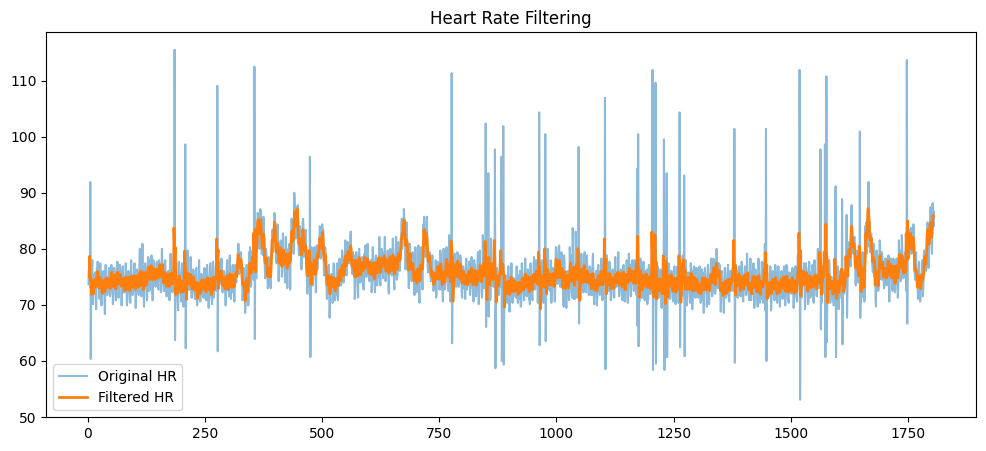

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hr_series, label="Original HR", alpha=0.5)
plt.plot(hr_smooth, label="Filtered HR", linewidth=2)
plt.legend()
plt.title("Heart Rate Filtering")
plt.show()

Downsampling (for ml)

In [12]:
hr_resampled = hr_smooth.copy()
hr_resampled.index = pd.to_timedelta(hr_resampled.index, unit='s')
hr_resampled = hr_resampled.resample("1s").mean().interpolate()

Output (ml/dl)

In [ ]:
hr_final = hr_smooth.dropna()